<a href="https://colab.research.google.com/github/nnott3/KilterTransformer/blob/main/bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/nnott3/KilterTransformer.git

Cloning into 'KilterTransformer'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 121 (delta 10), reused 11 (delta 3), pack-reused 96 (from 1)
Receiving objects: 100% (121/121), 39.45 MiB | 26.42 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [ ]:
%cd KilterTransformer

/content/KilterTransformer


In [ ]:
!ls

bert.ipynb  figs	project_structure  req		 utils_old
data	    main.ipynb	pyproject.toml	   saved_models  uv.lock
EDA.ipynb   models	readme.md	   src


# Good ass transformers

In [ ]:
"""
Transformer-based encoder using HuggingFace for route difficulty prediction.
"""
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from typing import Dict
from tqdm import tqdm
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup
import datetime
from src.data_processing import DataPreprocessing, HOLD_ID, HOLDCOORDINATES
from src.evaluation import Evaluation


class KilterBERT(nn.Module):
    """BERT model with custom regression head for difficulty prediction."""

    def __init__(self, vocab_size, hidden_dim=128, num_layers=4, num_heads=8, dropout=0.1):
        super().__init__()

        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=hidden_dim,
            num_hidden_layers=num_layers,
            num_attention_heads=num_heads,
            intermediate_size=hidden_dim * 4,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            max_position_embeddings=100,
            pad_token_id=0
        )

        self.bert = BertModel(config)
        self.angle_proj = nn.Linear(1, hidden_dim)

        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, angle, attention_mask=None):
        # Get BERT embeddings
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )


        # Get [CLS] token representation
        cls_embedding = outputs.last_hidden_state[:, 0]

        angle_emb = self.angle_proj(angle)
        combined = cls_embedding + angle_emb

        return self.regressor(combined).squeeze(-1)


class BoulderDataset(Dataset):
    """PyTorch dataset for boulder routes."""

    def __init__(self, routes_df: pd.DataFrame, vocab: Dict, max_length: int = 25):
        self.routes = routes_df #.reset_index(drop=True)
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.routes)

    def __getitem__(self, idx):
        row = self.routes[idx]
        tokens = self._tokenize(row['frames'])

        # Handle angle (works for both None and NaN)
        angle = row['angle_y'] if row['angle_y'] is not None and str(row['angle_y']) != 'nan' else 0.0
        difficulty = row['display_difficulty']

        # Pad tokens
        attention_mask = [1] * len(tokens)
        while len(tokens) < self.max_length:
            tokens.append(0)  # [PAD]
            attention_mask.append(0)

        return {
            'input_ids': torch.LongTensor(tokens[:self.max_length]),
            'angle': torch.FloatTensor([angle]),
            'attention_mask': torch.FloatTensor(attention_mask[:self.max_length]),
            'difficulty': torch.FloatTensor([difficulty])
        }


    def _tokenize(self, frames):
        """Convert holds to frame sequence: [CLS] hold_tokens... [SEP].
        e.g. angle40_grade23_start1109_start1125_hand1163 """

        tokens = [1] # [CLS]
        frame_split = [f for f in frames.split('_') if ('grade' not in f) and ('angle' not in f)]
        for hold in frame_split[:(self.max_length - 2)]:
            token = self.vocab.get(hold, 0)
            tokens.append(token)

        tokens.append(2) # [SEP]
        return tokens


class KilterEncoder:
    """HuggingFace BERT-based encoder"""

    def __init__(self, model_name='transformer', vocab_size=None, hidden_dim=128, num_layers=4, max_length=25):
        self.model_name = model_name
        self.max_length = max_length
        self.vocab = self._build_vocab()
        self.vocab_size = vocab_size or len(self.vocab)
        self.model = KilterBERT(self.vocab_size, hidden_dim, num_layers)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

    def _build_vocab(self) -> Dict[str, int]:
        """Build vocabulary: hold_id_func → token_id."""
        vocab = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2}
        token_id = 3
        for angle in range(20, 60, 5):
            vocab[f"angle{angle}"] = token_id
            token_id += 1

        for hold_id in HOLD_ID:
            for func in ['start', 'hand', 'finish', 'feet']:
                vocab[f"{func}{hold_id}"] = token_id
                token_id += 1
        return vocab

    def train_model(self, train_data, val_data=None,
                   epochs: int = 30, batch_size: int = 64, lr: float = 2e-4):
        """Train the transformer model."""
        train_dataset = BoulderDataset(train_data, self.vocab, self.max_length)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        if val_data is not None:
            val_dataset = BoulderDataset(val_data, self.vocab, self.max_length)
            val_loader = DataLoader(val_dataset, batch_size=batch_size)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=total_steps // 10,
            num_training_steps=total_steps
        )
        criterion = nn.SmoothL1Loss()

        best_val_loss = float('inf')

        print(f"Training {self.model_name} ...")
        for epoch in range(epochs):
            # Training
            self.model.train()
            train_loss = 0
            for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
                input_ids = batch['input_ids'].to(self.device)
                angle = batch['angle'].to(self.device)
                mask = batch['attention_mask'].to(self.device)
                difficulty = batch['difficulty'].squeeze().to(self.device)

                optimizer.zero_grad()
                pred = self.model(input_ids, angle, mask)
                loss = criterion(pred, difficulty)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

                train_loss += loss.item()

            train_loss /= len(train_loader)

            # Validation
            if val_data is not None:
                self.model.eval()
                val_loss = 0
                with torch.no_grad():
                    for batch in val_loader:
                        input_ids = batch['input_ids'].to(self.device)
                        angle = batch['angle'].to(self.device)
                        mask = batch['attention_mask'].to(self.device)
                        difficulty = batch['difficulty'].squeeze().to(self.device)

                        pred = self.model(input_ids, angle, mask)
                        loss = criterion(pred, difficulty)
                        val_loss += loss.item()

                val_loss /= len(val_loader)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    self.save_model()
                if epoch % 10 == 0 and epoch != 0:
                    timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
                    self.save_model(f"{self.model_name}_{epoch}_{timestamp}.pt")

                print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, LR={scheduler.get_last_lr()[0]:.2e}")
            else:
                print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}")

    def predict(self, routes_data, batch_size: int = 64) -> np.ndarray:
        """Predict difficulties for routes."""
        dataset = BoulderDataset(routes_data, self.vocab, self.max_length)
        loader = DataLoader(dataset, batch_size=batch_size)

        self.model.eval()
        predictions = []

        with torch.no_grad():
            for batch in loader:
                input_ids = batch['input_ids'].to(self.device)
                angle = batch['angle'].to(self.device)
                mask = batch['attention_mask'].to(self.device)

                pred = self.model(input_ids, angle, mask)
                predictions.extend(pred.cpu().numpy().tolist())

        return np.array(predictions)

    def save_model(self, name: str = None):
        """Save model weights."""
        if name is None:
            name = f'{self.model_name}.pt'
        torch.save(self.model.state_dict(), f'saved_models/{name}')

    def load_model(self, path: str = None):
        """Load model weights."""
        if path is None:
            path = f'{self.model_name}.pt'
        self.model.load_state_dict(torch.load(f'saved_models/{path}', map_location=self.device))
        self.model.eval()

In [5]:
from datasets import ClassLabel, disable_progress_bars

disable_progress_bars()

dp = DataPreprocessing()
climbs = dp.load_climbs()
print(f"Dataset: {len(climbs)} climbs")

num_classes = len(set(climbs["v_grade"]))
climbs = climbs.cast_column("v_grade", ClassLabel(num_classes=num_classes))

# Split train/test
climbs = climbs.train_test_split(test_size=0.1, seed=42, stratify_by_column="v_grade")
test_df = climbs['test']

# Split train/val
train_val = climbs['train'].train_test_split(test_size=0.15, seed=42, stratify_by_column="v_grade")
train_df = train_val['train']
val_df = train_val['test']

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

model_name = 'good_ass_transformer_256'
encoder = KilterEncoder(model_name=model_name, hidden_dim=256, num_layers=4)
print(f"Vocabulary size: {encoder.vocab_size}")
print(f"Model parameters: {sum(p.numel() for p in encoder.model.parameters()):,}")
print(f"Device: {encoder.device}")

encoder.train_model(train_df, val_df, epochs=40, batch_size=64, lr=2e-4)


Loaded 76992 routes from cache data/climbs_cleaned.csv
Dataset: 76992 climbs
Train: 58898, Val: 10394, Test: 7700
Vocabulary size: 1915
Model parameters: 3,808,257
Device: cuda
Training good_ass_transformer_256 ...


Epoch 1/40: 100%|██████████| 921/921 [00:37<00:00, 24.50it/s]


Epoch 1: Train Loss=6.7676, Val Loss=1.9055, LR=5.00e-05


Epoch 2/40: 100%|██████████| 921/921 [00:39<00:00, 23.52it/s]


Epoch 2: Train Loss=1.7660, Val Loss=1.4293, LR=1.00e-04


...

Epoch 38: Train Loss=0.7293, Val Loss=0.8493, LR=1.11e-05


Epoch 39/40: 100%|██████████| 921/921 [00:31<00:00, 29.00it/s]


Epoch 39: Train Loss=0.7277, Val Loss=0.8559, LR=5.56e-06


Epoch 40/40: 100%|██████████| 921/921 [00:31<00:00, 29.12it/s]


Epoch 40: Train Loss=0.7162, Val Loss=0.8514, LR=0.00e+00



Evaluating on test set...

GoodAss Transformer Performance:
  R²:   0.7939
  MAE:  1.2745
  RMSE: 1.6826
  Within ±1 V-grade: 83.10%


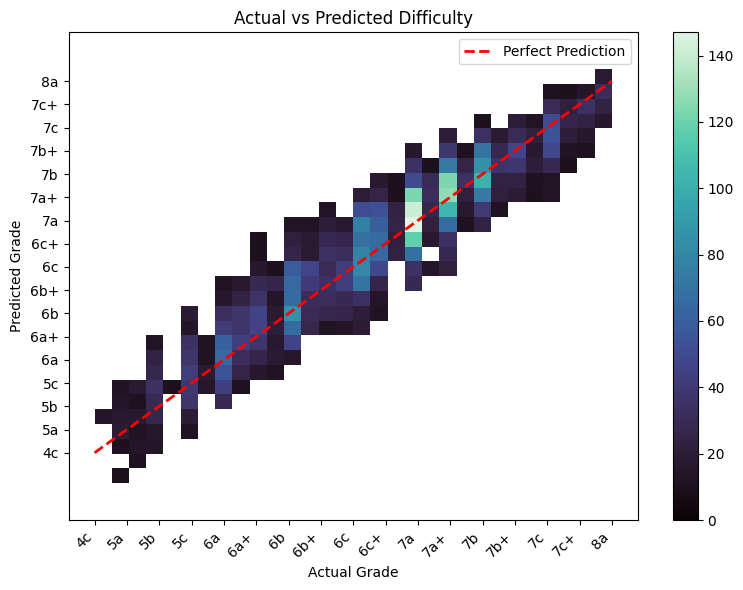

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
from src.data_processing import DataPreprocessing
from src.evaluation import Evaluation


# Load best model
encoder.load_model('good_ass_transformer_256.pt')


# Evaluate
print("\nEvaluating on test set...")
y_test = test_df['display_difficulty']
y_pred = encoder.predict(test_df)

evaluator = Evaluation()
scores = evaluator.get_scores(y_test, y_pred, "GoodAss Transformer")

evaluator.plot_predictions(y_test, y_pred)

# Improve จิงละ

In [ ]:
"""
Enhanced Transformer for route difficulty prediction with spatial awareness.

1. ARCHITECTURE:
    - Added 2D positional embeddings (pos_x, pos_y)
    - Added other metadata features: route density, max reach distance
    - Separate _train_epoch, _validate, _compute_grade_weights
    - Added model_sumary

2. DATA PROCESSING:
   - hand_or_foot encoding instead of func(start, finish, hand, foot)
   - Sort holds by y and x
   - Data augmentation: shuffle of non-start/finish holds during training
   - Hold frequency by grade: Track how often each hold appears in different V-grades
   - Hold co-occurrence patterns: Capture which holds commonly appear together

3. TRAINING:
   - Early stopping
   - Mixed precision training
   - Penalize errors more heavily on easier climbs (inverse grade weighting)

# 4. CODE QUALITY:
#    - Attention extraction: Return attention weights for visualization and interpretability
#    - Better error handling: Fixed v_grade string parsing for weight computation
#    - Cleaner data flow: Pop v_grade before moving tensors to device

"""
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from transformers import BertConfig, BertModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from collections import Counter

from utils.data_processing import HOLD_ID, DataPreprocessing
from utils.evaluation import Evaluation


class SpatialKilterBERT(nn.Module):
    """BERT with 2D positional embeddings and metadata integration."""

    def __init__(self, vocab_size, hidden_dim=128, num_layers=4, num_heads=8, dropout=0.1):
        super().__init__()

        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=hidden_dim,
            num_hidden_layers=num_layers,
            num_attention_heads=num_heads,
            intermediate_size=hidden_dim * 4,
            hidden_dropout_prob=dropout,
            attention_probs_dropout_prob=dropout,
            max_position_embeddings=100,
            pad_token_id=0
        )

        self.bert = BertModel(config)

        # 2D positional embeddings
        self.pos_x_embed = nn.Embedding(18, hidden_dim // 2)  # Max x coordinate
        self.pos_y_embed = nn.Embedding(12, hidden_dim // 2)  # Max y coordinate

        # Metadata projection
        self.angle_proj = nn.Linear(1, hidden_dim)
        self.metadata_proj = nn.Linear(2, hidden_dim)  # density, max_reach

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, input_ids, pos_x, pos_y, angle, metadata, attention_mask=None):
        # BERT embeddings
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        # Add 2D positional embeddings
        pos_embed = torch.cat([
            self.pos_x_embed(pos_x),
            self.pos_y_embed(pos_y)
        ], dim=-1)

        spatial_hidden = bert_out.last_hidden_state + pos_embed
        cls_token = spatial_hidden[:, 0]

        # Combine with metadata
        angle_emb = self.angle_proj(angle)
        meta_emb = self.metadata_proj(metadata)
        combined = torch.cat([cls_token + angle_emb, meta_emb], dim=-1)

        return self.regressor(combined).squeeze(-1), bert_out.attentions


class EnhancedBoulderDataset(Dataset):
    """Dataset with spatial features and augmentation."""

    def __init__(self, routes_df, vocab, hold_stats, max_length=25, augment=False):
        self.routes = routes_df.reset_index(drop=True)
        self.vocab = vocab
        self.hold_stats = hold_stats
        self.max_length = max_length
        self.augment = augment

    def __len__(self):
        return len(self.routes)

    def __getitem__(self, idx):
        row = self.routes.iloc[idx]
        holds = row['holds_data']

        # Sort holds by position (y first for climbing, then x)
        holds_sorted = sorted(holds, key=lambda h: (
            list(h.values())[0] not in [14, 15],  # Start/finish first
            -list(h.keys())[0] // 100,  # y coordinate (descending)
            list(h.keys())[0] % 100  # x coordinate
        ))

        # Augment: shuffle non-start/finish holds
        if self.augment and len(holds_sorted) > 2:
            start_finish = [h for h in holds_sorted if list(h.values())[0] in [14, 15]]
            middle = [h for h in holds_sorted if list(h.values())[0] not in [14, 15]]
            np.random.shuffle(middle)
            holds_sorted = start_finish + middle

        tokens, pos_x, pos_y = self._tokenize_with_positions(holds_sorted)

        # Metadata features
        density = len(holds) / self.max_length
        reaches = [abs(holds_sorted[i+1][list(holds_sorted[i+1].keys())[0]] -
                      holds_sorted[i][list(holds_sorted[i].keys())[0]])
                  for i in range(len(holds_sorted)-1)]
        max_reach = max(reaches) / 1000 if reaches else 0

        angle = row['angle_y'] if not pd.isna(row['angle_y']) else 0.0
        difficulty = row['display_difficulty']

        # Pad sequences
        attention_mask = [1] * len(tokens)
        pad_len = self.max_length - len(tokens)
        tokens.extend([0] * pad_len)
        pos_x.extend([0] * pad_len)
        pos_y.extend([0] * pad_len)
        attention_mask.extend([0] * pad_len)

        return {
            'input_ids': torch.LongTensor(tokens[:self.max_length]),
            'pos_x': torch.LongTensor(pos_x[:self.max_length]),
            'pos_y': torch.LongTensor(pos_y[:self.max_length]),
            'angle': torch.FloatTensor([angle]),
            'metadata': torch.FloatTensor([density, max_reach]),
            'attention_mask': torch.FloatTensor(attention_mask[:self.max_length]),
            'difficulty': torch.FloatTensor([difficulty]),
            'v_grade': row['v_grade']
        }

    def _tokenize_with_positions(self, holds):
        """Convert holds to tokens with 2D positions."""
        tokens = [1]  # [CLS]
        pos_x = [0]
        pos_y = [0]

        for hold in holds[:(self.max_length - 2)]:
            hold_id, func = list(hold.items())[0]

            # Binary encoding: foot (13) vs hand/start/finish
            hand_or_foot = 0 if func == 13 else 1
            token = self.vocab.get(f"{hold_id}_{hand_or_foot}", 0)
            tokens.append(token)

            # Extract x, y coordinates
            x = hold_id % 100
            y = hold_id // 100
            pos_x.append(min(x, 17))
            pos_y.append(min(y, 11))

        tokens.append(2)  # [SEP]
        pos_x.append(0)
        pos_y.append(0)

        return tokens, pos_x, pos_y


class EnhancedKilterEncoder:
    """Enhanced encoder with hold statistics and training improvements."""

    def __init__(self, model_name='enhanced_transformer', hidden_dim=128, num_layers=4):
        self.model_name = model_name
        self.max_length = 25
        self.vocab = self._build_vocab()
        self.hold_stats = {}
        self.model = SpatialKilterBERT(len(self.vocab), hidden_dim, num_layers)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.scaler = GradScaler()

    def _build_vocab(self):
        """Build vocabulary with hand_or_foot encoding."""
        vocab = {'[PAD]': 0, '[CLS]': 1, '[SEP]': 2}
        token_id = 3
        for hold_id in HOLD_ID:
            for hand_or_foot in [0, 1]:  # 0=foot, 1=hand/start/finish
                vocab[f"{hold_id}_{hand_or_foot}"] = token_id
                token_id += 1
        return vocab

    def compute_hold_statistics(self, routes_df):
        """Compute hold frequency and co-occurrence by grade."""
        hold_freq = {grade: Counter() for grade in routes_df['v_grade'].unique()}
        hold_cooccur = Counter()

        for _, row in routes_df.iterrows():
            grade = row['v_grade']
            holds = [list(h.items())[0] for h in row['holds_data']]

            # Frequency by grade
            for hold_id, func in holds:
                hand_or_foot = 0 if func == 13 else 1
                hold_freq[grade][f"{hold_id}_{hand_or_foot}"] += 1

            # Co-occurrence
            for i in range(len(holds)):
                for j in range(i+1, len(holds)):
                    hf1 = 0 if holds[i][1] == 13 else 1
                    hf2 = 0 if holds[j][1] == 13 else 1
                    pair = tuple(sorted([f"{holds[i][0]}_{hf1}", f"{holds[j][0]}_{hf2}"]))
                    hold_cooccur[pair] += 1

        self.hold_stats = {'frequency': hold_freq, 'cooccurrence': hold_cooccur}
        return self.hold_stats

    def train_model(self, train_df, val_df, epochs=30, batch_size=64, lr=2e-4, early_stop=3):
        """Train with mixed precision and early stopping."""
        # Compute statistics
        self.compute_hold_statistics(train_df)

        train_dataset = EnhancedBoulderDataset(train_df, self.vocab, self.hold_stats, augment=True)
        val_dataset = EnhancedBoulderDataset(val_df, self.vocab, self.hold_stats, augment=False)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=0.01)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=len(train_loader) * epochs // 10,
            num_training_steps=len(train_loader) * epochs
        )

        # Weighted loss: penalize more on easier climbs
        grade_weights = self._compute_grade_weights(train_df)

        best_val_loss = float('inf')
        patience_counter = 0

        print(f"Training {self.model_name}")

        for epoch in range(epochs):
            # Training
            train_loss = self._train_epoch(train_loader, optimizer, scheduler, grade_weights, epoch, epochs)

            # Validation
            val_loss = self._validate(val_loader, grade_weights)

            print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                f"LR: {scheduler.get_last_lr()[0]:.2e}")

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                self.save_model()
            else:
                patience_counter += 1
                if patience_counter >= early_stop:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

    def _train_epoch(self, loader, optimizer, scheduler, grade_weights, epoch, total_epochs):
        """Single training epoch with mixed precision."""
        self.model.train()
        total_loss = 0

        for batch in tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False):
            v_grades = batch.pop('v_grade')
            batch = {k: v.to(self.device) for k, v in batch.items()}

            optimizer.zero_grad()

            with autocast():
                pred, _ = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                # Weighted loss
                weights = torch.tensor([grade_weights.get(g, 1.0) for g in v_grades],
                                    device=self.device)
                loss = (nn.SmoothL1Loss(reduction='none')(pred, batch['difficulty'].squeeze()) * weights).mean()

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(optimizer)
            self.scaler.update()
            scheduler.step()

            total_loss += loss.item()

        return total_loss / len(loader)

    def _validate(self, loader, grade_weights):
        """Validation with weighted loss."""
        self.model.eval()
        total_loss = 0

        with torch.no_grad():
            for batch in loader:
                v_grades = batch.pop('v_grade')
                batch = {k: v.to(self.device) for k, v in batch.items()}

                pred, _ = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                weights = torch.tensor([grade_weights.get(g, 1.0) for g in v_grades],
                                      device=self.device)
                loss = (nn.SmoothL1Loss(reduction='none')(pred, batch['difficulty'].squeeze()) * weights).mean()
                total_loss += loss.item()

        return total_loss / len(loader)

    def _compute_grade_weights(self, df):
        """Compute weights to penalize errors on easier grades more."""
        grade_counts = df['v_grade'].value_counts()

        # Extract numeric part from grade strings like 'V5', 'V7+'
        def grade_to_num(grade_str):
            import re
            match = re.search(r'\d+', str(grade_str))
            return int(match.group()) if match else 0

        max_grade_num = max(grade_to_num(g) for g in grade_counts.index)

        # Higher weight for lower grades
        weights = {grade: (max_grade_num - grade_to_num(grade) + 1) / max_grade_num
                  for grade in grade_counts.index}
        return weights

    def predict(self, routes_df, batch_size=64):
        """Predict with attention extraction."""
        dataset = EnhancedBoulderDataset(routes_df, self.vocab, self.hold_stats, augment=False)
        loader = DataLoader(dataset, batch_size=batch_size)

        self.model.eval()
        predictions = []
        attentions = []

        with torch.no_grad():
            for batch in loader:
                batch.pop('v_grade')
                batch = {k: v.to(self.device) for k, v in batch.items()}

                pred, attn = self.model(
                    batch['input_ids'], batch['pos_x'], batch['pos_y'],
                    batch['angle'], batch['metadata'], batch['attention_mask']
                )

                predictions.extend(pred.cpu().numpy())
                if attn:
                    attentions.append(attn[-1].cpu().numpy())  # Last layer attention

        return np.array(predictions), attentions

    def save_model(self):
        torch.save({
            'model_state': self.model.state_dict(),
            'vocab': self.vocab,
            'hold_stats': self.hold_stats
        }, f'saved_models/{self.model_name}.pt')

    def load_model(self, path=None):
        if path is None:
            path = self.model_name
        checkpoint = torch.load(f'saved_models/{path}.pt', map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state'])
        self.vocab = checkpoint['vocab']
        self.hold_stats = checkpoint.get('hold_stats', {})
        self.model.eval()

    def model_summary(self):
        """Print model architecture and parameters."""
        print(f"\n{'='*60}")
        print(f"Model: {self.model_name}")
        print(f"{'='*60}")
        print(f"Vocabulary size: {len(self.vocab)}")
        print(f"Max sequence length: {self.max_length}")

        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)

        print(f"\nTotal parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        print(f"Model size: {total_params * 4 / 1024**2:.2f} MB")

        print(f"\nArchitecture:")
        for name, module in self.model.named_children():
            params = sum(p.numel() for p in module.parameters())
            print(f"  {name}: {params:,} parameters")
        print(f"{'='*60}\n")



"""Training and evaluation pipeline."""
# Load data
dp = DataPreprocessing()
routes = dp.load_routes()
print(f"Loaded {len(routes)} routes")

# Split data
train_df, test_df = train_test_split(routes, test_size=0.15, random_state=42,
                                        stratify=routes['v_grade'])
train_df, val_df = train_test_split(train_df, test_size=0.125, random_state=42,
                                    stratify=train_df['v_grade'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Train
encoder = EnhancedKilterEncoder(hidden_dim=128, num_layers=4)
encoder.model_summary()

encoder.train_model(train_df, val_df, epochs=30, batch_size=64, lr=2e-4, early_stop=3)

# Evaluate
encoder.load_model()
y_test = test_df['display_difficulty'].values
y_pred, attentions = encoder.predict(test_df)

evaluator = Evaluation(dp)
evaluator.get_scores(y_test, y_pred, "Enhanced Spatial Transformer")
evaluator.plot_predictions(y_test, y_pred)

print(f"\nAttention weights shape: {attentions[0].shape if attentions else 'N/A'}")

# Epoch 30/30 | Train: 0.3197 | Val: 0.3190 | LR: 0.00e+00

# Enhanced Spatial Transformer Performance:
#   R²:   0.8270
#   MAE:  1.2981
#   RMSE: 1.6953
#   Within ±1 V-grade: 81.17%